# Phase 5 — Constraints (verified), Explainability, Fairness (pre-registered)

The design review found LightGBM's `advanced` constraint method violating monotonicity by up to **0.166 raw log-odds** on our features — so the pipeline uses `basic`, and a **gate** verifies zero violations on every fold model before recalibration may proceed. The guarantee is a *tested property*, not a parameter.

constrained OOF AUC 0.77677 vs unconstrained 0.77735
→ cost of the guarantee: 0.00059 (spec typical ≤ 0.003)
gate passed: True (worst violation by feature all 0.0)
recalibrated: Brier 0.06671, ECE 0.00078
gap under the DEPLOYED pipeline: 5.28% (unconstrained CI [0.0421, 0.0583]) — the story survives the retrain


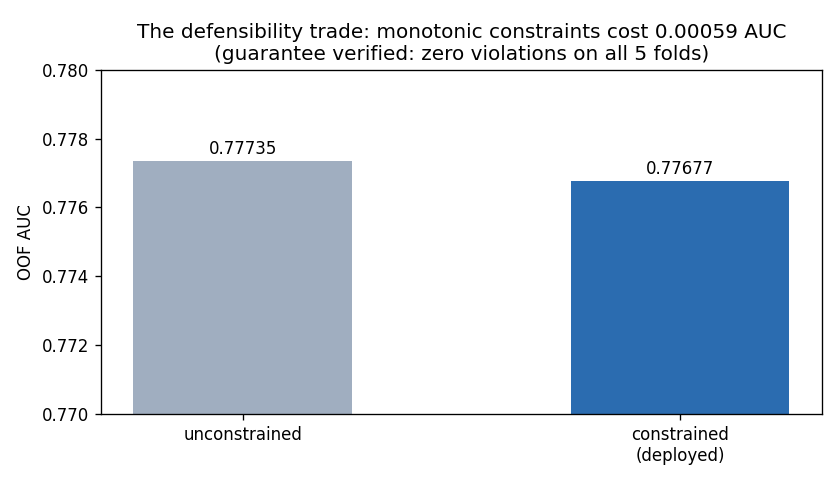

In [1]:
import sys, os, json
sys.path.insert(0, "..")
import pandas as pd
from IPython.display import Image
from config.constants import TABLES_DIR, FIGURES_DIR

fp = json.load(open(os.path.join(TABLES_DIR, "final_pipeline.json")))
print(f"constrained OOF AUC {fp['constrained_oof_auc']:.5f} vs unconstrained {fp['unconstrained_oof_auc']:.5f}")
print(f"→ cost of the guarantee: {fp['auc_cost_of_constraints']:.5f} (spec typical ≤ {fp['spec_typical_cost']})")
print(f"gate passed: {fp['monotonicity_gate']['passed']} (worst violation by feature all 0.0)")
print(f"recalibrated: Brier {fp['calibration']['brier_crossfit']:.5f}, ECE {fp['calibration']['ece_crossfit']:.5f}")
d = fp["decision"]
print(f"gap under the DEPLOYED pipeline: {d['gap_relative']:.2%} "
      f"(unconstrained CI {d['unconstrained_gap_CI_for_reference']}) — the story survives the retrain")
Image(os.path.join(FIGURES_DIR, "51_constraint_cost.png"))

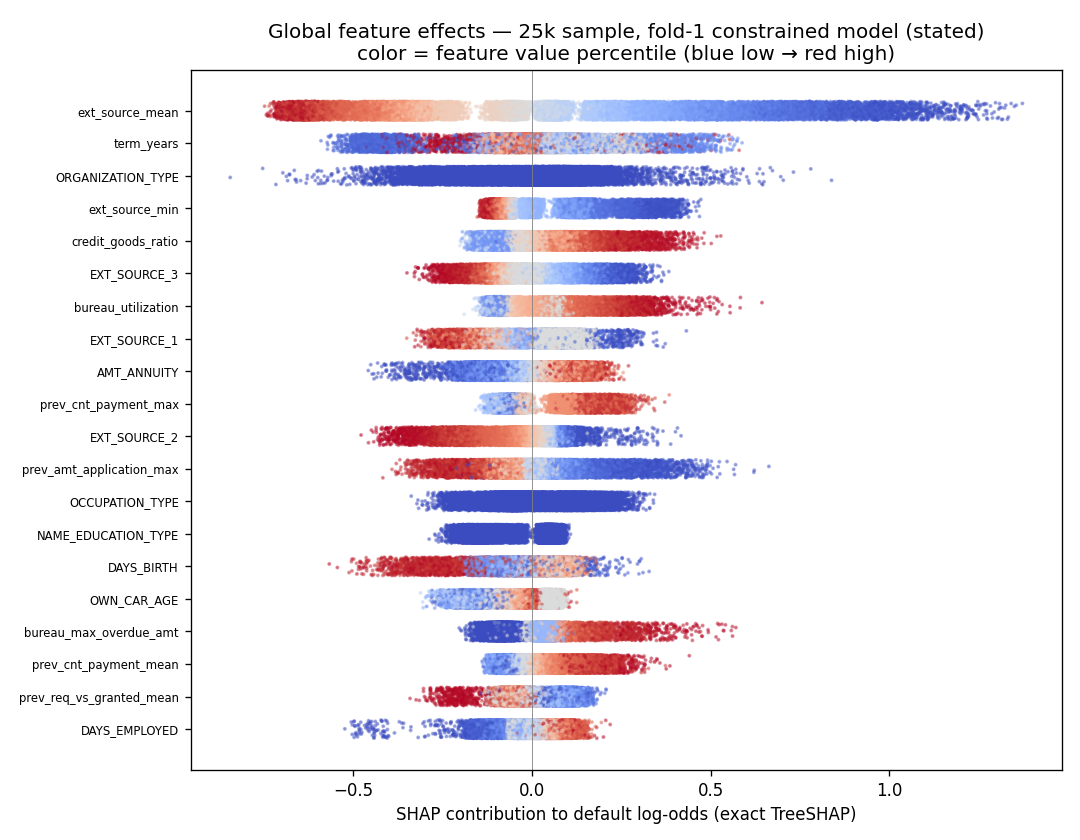

In [2]:
Image(os.path.join(FIGURES_DIR, "52_shap_beeswarm.png"))

In [3]:
demo = json.load(open(os.path.join(TABLES_DIR, "reason_codes_demo.json")))
for a in demo[:2]:
    print(f"applicant {a['SK_ID_CURR']}: PD {a['p_cal']:.3f} → score {a['score']:.0f}")
    for rc in a["reason_codes"]:
        print(f"   • {rc['plain_language']}  (+{rc['contribution']:.2f} log-odds)")

applicant 103477: PD 1.000 → score 300
   • low average external credit score  (+1.19 log-odds)
   • low external credit score (worst bureau)  (+0.44 log-odds)
   • financed amount high relative to goods price  (+0.29 log-odds)
applicant 190532: PD 1.000 → score 300
   • low average external credit score  (+1.35 log-odds)
   • low external credit score (worst bureau)  (+0.49 log-odds)
   • bureau days credit max  (+0.48 log-odds)


## Fairness — the pre-registration did its job, including where reality exceeded it

Pre-registered: the proxy check *will* fire (0.75–0.85 expected). Measured: **0.907 — above the band** and disclosed as such. Deliverable = measurement + disclosure; per-group thresholds would be disparate treatment, which is why the textbook fix is named, not implemented.

proxy OOF AUC: 0.907 (pre-registered [0.75, 0.85], flag 0.65)
top carriers: ['OCCUPATION_TYPE', 'OWN_CAR_AGE', 'EXT_SOURCE_1', 'ORGANIZATION_TYPE']
        n approval_rate base_default_rate FPR_goods_rejected  \
F  161887      0.665489          0.070012           0.307579   
M   84119      0.543694          0.101356           0.419629   

  FNR_defaulters_approved mean_t_star  
F                0.307747    0.081536  
M                0.218508    0.077659  
summary: {'disparate_impact_ratio': 0.816984415994414, 'four_fifths_flag': False, 'abs_FPR_gap': 0.11204941096213122, 'abs_FNR_gap': 0.08923851024866239}


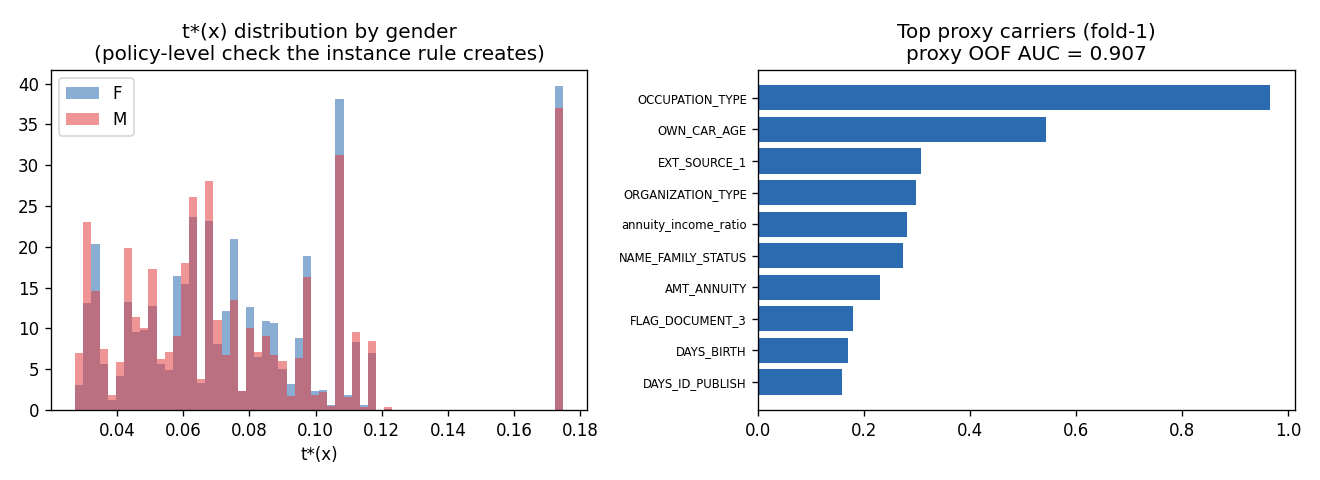

In [4]:
fa = json.load(open(os.path.join(TABLES_DIR, "fairness_audit.json")))
p = fa["proxy_check"]; dm = fa["decision_metrics"]
print(f"proxy OOF AUC: {p['proxy_oof_auc']:.3f} (pre-registered {p['preregistered_expectation']}, flag {p['flag_threshold']})")
print("top carriers:", list(p["top10_proxy_carriers_fold1"])[:4])
rows = {g: dm[g] for g in ("F","M")}
print(pd.DataFrame(rows).T[["n","approval_rate","base_default_rate","FPR_goods_rejected","FNR_defaulters_approved","mean_t_star"]].round(3))
print("summary:", dm["summary"])
Image(os.path.join(FIGURES_DIR, "53_fairness.png"))

**The senior readings:** (1) DIR 0.817 *passes the four-fifths flag by 0.017* — reported as narrow, not clean. (2) The policy-vs-model question the instance rule creates has a measured answer: mean t\*(x) differs by only 0.004 between groups — the approval gap is **score-driven** (tracking real base-rate differences 10.1% vs 7.0%), not threshold-driven. (3) The equalized-odds gaps are the canonical impossibility pattern: with different base rates, a calibrated score cannot equalize both error rates (Kleinberg 2016; Chouldechova 2017) — this system chose calibration, and reports what that costs on the other axes. Limits disclosed: gender only, dev only, "inspired by" governance practice — never compliance.